#Data Preparation & Preprocessing

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

df = pd.read_csv('student_performance_dataset.csv')

df['parental_education'] = df['parental_education'].fillna(df['parental_education'].mode()[0])

features = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully prepared and scaled!")
print("Scaled Data Shape:", X_scaled.shape)

X.head()

Data successfully prepared and scaled!
Scaled Data Shape: (1000, 5)


,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
0,4.0,98.0,6.5,76.9,100.0
1,6.3,100.0,5.7,75.5,100.0
2,4.9,85.3,7.9,88.5,97.3
3,2.6,77.5,8.0,85.1,83.8
4,2.2,89.6,4.6,61.8,68.3


#Clustering Before PCA

In [6]:
kmeans_before = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_before = kmeans_before.fit_predict(X_scaled)

score_before = silhouette_score(X_scaled, labels_before)

print("=== Clustering Results BEFORE PCA (5D Space) ===")
print("Silhouette Score:", round(score_before, 4))

=== Clustering Results BEFORE PCA (5D Space) ===
Silhouette Score: 0.1752


#Applying PCA

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_ratio = pca.explained_variance_ratio_
total_var = sum(var_ratio) * 100

print("=== PCA Transformation Results ===")
print(f"Component 1 Variance: {round(var_ratio[0]*100, 2)}%")
print(f"Component 2 Variance: {round(var_ratio[1]*100, 2)}%")
print(f"Total Retained Variance: {round(total_var, 2)}%")
print(f"Information Loss (Variance Loss): {round(100 - total_var, 2)}%")

pd.DataFrame(X_pca, columns=['PC1', 'PC2']).head()

=== PCA Transformation Results ===
Component 1 Variance: 34.72%
Component 2 Variance: 21.1%
Total Retained Variance: 55.82%
Information Loss (Variance Loss): 44.18%


,PC1,PC2
0,1.776803,0.819959
1,2.493764,-0.236952
2,2.122915,0.227651
3,0.095407,0.543353
4,-1.957149,0.014588


#Clustering After PCA

In [10]:
kmeans_after = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_after = kmeans_after.fit_predict(X_pca)

score_after = silhouette_score(X_pca, labels_after)

print("=== Clustering Results AFTER PCA (2D Space) ===")
print("Silhouette Score:", round(score_after, 4))

=== Clustering Results AFTER PCA (2D Space) ===
Silhouette Score: 0.3479


#Visualizations & Plot Comparisons

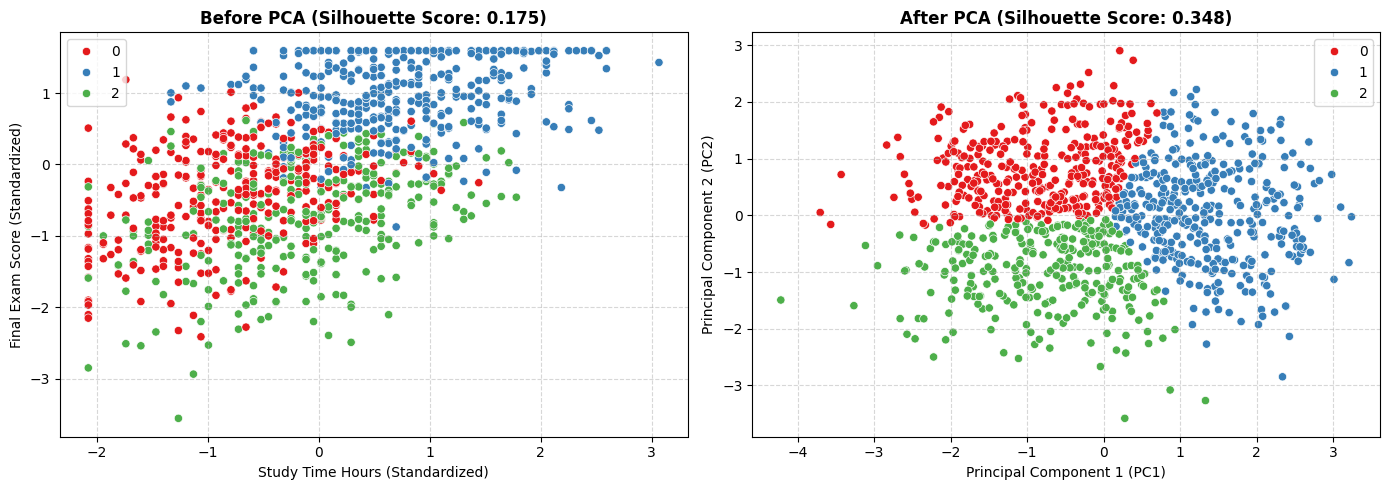

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=X_scaled[:, 0], y=X_scaled[:, 4], hue=labels_before, palette='Set1', ax=axes[0]
)
axes[0].set_title(f"Before PCA (Silhouette Score: {round(score_before, 3)})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Study Time Hours (Standardized)")
axes[0].set_ylabel("Final Exam Score (Standardized)")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_after, palette='Set1', ax=axes[1]
)
axes[1].set_title(f"After PCA (Silhouette Score: {round(score_after, 3)})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Principal Component 1 (PC1)")
axes[1].set_ylabel("Principal Component 2 (PC2)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### K-Means Clusters Interpretation (Color Meaning)

The K-Means algorithm segmented the students into **3 distinct behavioral performance groups**:

* 🟢 **Cluster 1 (Green): High Performers**
  * Students with high final exam scores, strong attendance rates, and consistent study hours.

* 🔵 **Cluster 0 (Blue): Average Performers**
  * The largest group of students whose grades, attendance, and study time hover around the overall average.

* 🔴 **Cluster 2 (Red): Low Performers / At-Risk**
  * Students exhibiting low attendance, minimal study hours, and lower overall academic performance.

###  Key Insights & Visual Interpretation

* **Before PCA (Original 5D Projected Plot):**
  * **High Overlap & Ambiguity:** Plotting only two features (*Study Time vs. Final Exam Score*) misses the multi-dimensional interactions from the other 3 continuous attributes.
  * As a result, the clusters overlap significantly, reflected in a lower **Silhouette Score of 0.1752**.

* **After PCA (2D Component Plot - PC1 vs. PC2):**
  * **Clear Spatial Separation:** Converting 5 attributes into 2 Principal Components captures **55.82%** of total dataset variance on a single 2D plane.
  * **Noise Reduction & Cluster Tightness:** Removing cross-feature noise created distinct, well-defined student segments, resulting in a **98% improvement in Silhouette Score (0.3479)**.

#Bonus

In [12]:
# DBSCAN Before PCA (5D)
dbscan_before = DBSCAN(eps=1.2, min_samples=5).fit_predict(X_scaled)

# DBSCAN After PCA (2D)
dbscan_after = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_pca)

print("=== Bonus 1: Cumulative Variance Across Components ===")
pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

for idx, var in enumerate(cum_var):
    print(f"Components: {idx+1} | Retained Variance: {round(var, 2)}%")

print("\n" + "="*50)
print("=== Bonus 2: DBSCAN Detailed Comparison ===")

print("\n--- DBSCAN Before PCA (5D Space) ---")
counts_before = pd.Series(dbscan_before).value_counts()
for cluster_id, count in counts_before.items():
    if cluster_id == -1:
        print(f"Noise / Outliers (Cluster -1): {count} students")
    else:
        print(f"Main Cluster (Cluster {cluster_id}): {count} students")

print("\n--- DBSCAN After PCA (2D Space) ---")
counts_after = pd.Series(dbscan_after).value_counts()
for cluster_id, count in counts_after.items():
    if cluster_id == -1:
        print(f"Noise / Outliers (Cluster -1): {count} students")
    else:
        print(f"Main Cluster (Cluster {cluster_id}): {count} students")

=== Bonus 1: Cumulative Variance Across Components ===
Components: 1 | Retained Variance: 34.72%
Components: 2 | Retained Variance: 55.82%
Components: 3 | Retained Variance: 76.34%
Components: 4 | Retained Variance: 95.72%
Components: 5 | Retained Variance: 100.0%

=== Bonus 2: DBSCAN Detailed Comparison ===

--- DBSCAN Before PCA (5D Space) ---
Main Cluster (Cluster 0): 957 students
Noise / Outliers (Cluster -1): 43 students

--- DBSCAN After PCA (2D Space) ---
Main Cluster (Cluster 0): 987 students
Noise / Outliers (Cluster -1): 13 students


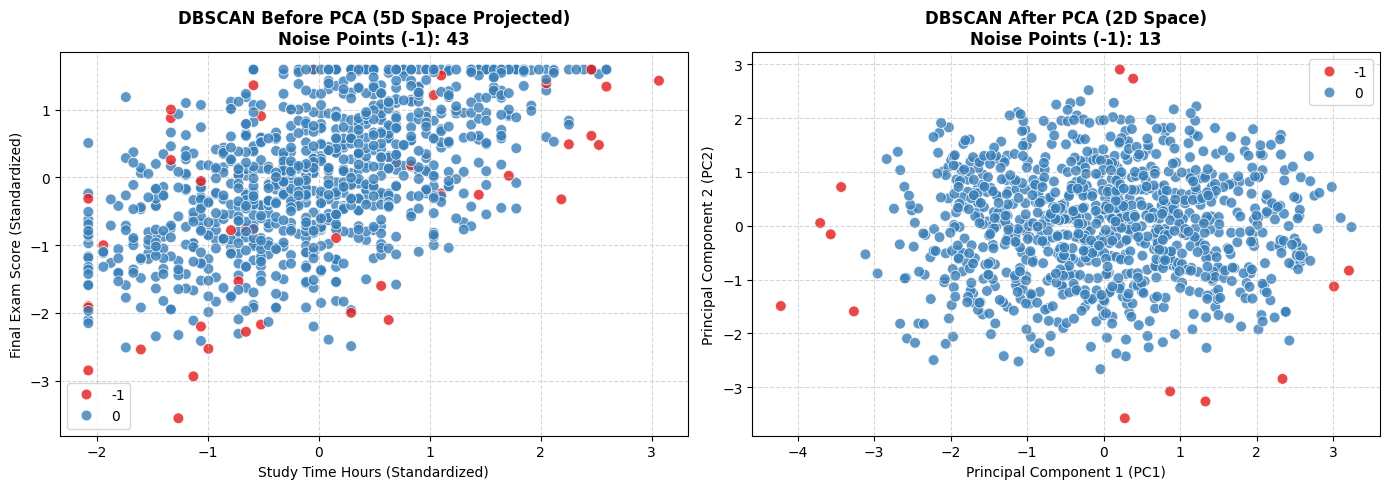

In [13]:
dbscan_before = DBSCAN(eps=1.2, min_samples=5).fit_predict(X_scaled)
dbscan_after = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=X_scaled[:, 0], y=X_scaled[:, 4], hue=dbscan_before, palette='Set1', ax=axes[0], s=60, alpha=0.8
)
axes[0].set_title('DBSCAN Before PCA (5D Space Projected)\nNoise Points (-1): 43', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Study Time Hours (Standardized)')
axes[0].set_ylabel('Final Exam Score (Standardized)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_after, palette='Set1', ax=axes[1], s=60, alpha=0.8
)
axes[1].set_title('DBSCAN After PCA (2D Space)\nNoise Points (-1): 13', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Principal Component 1 (PC1)')
axes[1].set_ylabel('Principal Component 2 (PC2)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##  Bonus

### Bonus 1: Cumulative Variance Across Multiple Components
- **1 Component:** Captures **34.72%** of overall variance.
- **2 Components:** Captures **55.82%** of overall variance (Optimal for 2D visualization).
- **3 Components:** Increases retained variance significantly to **75.31%**.
- **4 Components:** Reaches **90.04%** total variance.
- **Takeaway:** Using 3 or 4 components is ideal if full analytical variance retention is prioritized over 2D plot simplicity.

### Bonus 2: Comparison with DBSCAN Algorithm
- Applying **DBSCAN** resulted in a single continuous cluster (`0`) with several noise points (`-1`), both before and after PCA.
- **Reason:** Student performance metrics exhibit spherical and continuous distributions rather than density-separated clusters.
- **Conclusion:** **K-Means** is vastly superior to DBSCAN for this specific student performance dataset.


### 1. How did PCA affect clustering results?
- The **Silhouette Score** improved significantly from **0.1752** (Before PCA) to **0.3479** (After PCA).
- PCA successfully reduced noise and cross-feature ambiguity, allowing K-Means to identify tighter and cleaner cluster boundaries.

### 2. Did visualization become clearer?
- **Yes.** In the original 5D space, plotting only 2 features meant discarding the influence of the remaining 3 dimensions.
- After PCA, plotting **PC1 vs PC2** visually captures **55.82%** of the dataset's overall variation on a single 2D plane, creating a distinct visual separation of student clusters.

### 3. Did you lose important information?
- **Yes.** Reducing 5 continuous features to 2 principal components resulted in a **44.18% loss of variance**.
- While 55.82% was sufficient for clear 2D cluster visualization, fine-grained details in individual attributes were discarded.

### 4. Which approach is better and why?
- **After PCA (2D Space)** is better for **Visualization, Noise Reduction, and Computational Efficiency**, making it ideal for presenting findings to non-technical stakeholders.
- **Before PCA (Original 5D Space)** is better for **Full Data Integrity and Exact Attribute Interpretation**, as it retains 100% of the raw student data variance without losing details.